In [20]:
import numpy as np
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import time

Define command to build the QUBO problem and to retreive its dimension, specify starting knowledge base an defining query

In [21]:
command_qmasm = 'qmasm --format="numpy" -o="out.npz" --pin="Query.Valid := true" --solver="tabu" ' + str(Path.cwd()) + '/work/animal_unfold.qmasm'
command_QAP = 'QA-Prolog --qmasm-args="--stop" --work-dir="' + str(Path.cwd()) + '/work"'
query = 'subClass(mammal, animal).'
file = 'animal_unfold.pl'

In [22]:
def read_file(file_name):
    with open(file_name, 'r') as file_in:
        lines = file_in.readlines()
    return lines

Helper function that generate the unfolded calls

In [23]:
def write_unfold_calls(file_out, n_unfold):
    file_out.write('subClass0(C0,C1) :- \n\tsubclass(C0, C1).\n')
    for i in range(1, n_unfold):
        rule = 'subClass'+ str(i) + '(C0,C2) :-\n'      +\
               '\tsubClass' + str(i-1) + '(C0,C3),\n'   +\
               '\tsubclass(C3, C2).\n'
        file_out.write(rule)
    for i in range(n_unfold):
        file_out.write('subClass(C0,C1) :- subClass' + str(i) +'(C0, C1).\n')

Function that starts from the original KB and generate a new one with the unfolded calls

In [24]:
def write_file(file_name_in, file_name_out, n_unfold):
    t_box = read_file(file_name_in)
    file_out = open(file_name_out, 'w')
    file_out.writelines(t_box)
    file_out.write('\n\n')
    write_unfold_calls(file_out, n_unfold)
    file_out.close()
    

Generate a new knowledge base with `n_calls` unfolded classes and return the resulting QUBO dimension

In [25]:
def experiment(file_name_in, file_name_out, n_calls):
    write_file(file_name_in, file_name_out, n_calls)
    command = command_QAP + ' --query="' + query + '" ' + file_name_out
    subprocess.run(command, shell=True, capture_output=True, text=True)
    subprocess.run(command_qmasm, shell=True)
    data = np.load("out.npz")
    return len(data["syms"])

Run the experiment for an increasing number of unfolded calls, from 2 up to `n_unfold_max`, and return the list of resulting QUBO dimensions

In [26]:
def run_experiments(file_name_in, file_name_out, n_unfold_max):
    n_qubits = []
    for i in range(2, n_unfold_max + 1):
        print(f"unfolded calls {i}/{n_unfold_max} ...", end="")
        start = time.time()
        n_qubits.append(experiment(file_name_in, file_name_out, i))
        stop = time.time()
        print(f"ok ({int(stop - start)} sec)")
    return n_qubits

In [27]:
n_qubits = run_experiments('animal.pl', 'animal_unfold.pl', 20)

unfolded calls 2/20 ...ok (2 sec)
unfolded calls 3/20 ...ok (2 sec)
unfolded calls 4/20 ...ok (2 sec)
unfolded calls 5/20 ...ok (3 sec)
unfolded calls 6/20 ...ok (4 sec)
unfolded calls 7/20 ...ok (6 sec)
unfolded calls 8/20 ...ok (8 sec)
unfolded calls 9/20 ...ok (12 sec)
unfolded calls 10/20 ...ok (13 sec)
unfolded calls 11/20 ...ok (21 sec)
unfolded calls 12/20 ...ok (27 sec)
unfolded calls 13/20 ...ok (54 sec)
unfolded calls 14/20 ...ok (66 sec)
unfolded calls 15/20 ...ok (87 sec)
unfolded calls 16/20 ...ok (134 sec)
unfolded calls 17/20 ...ok (164 sec)
unfolded calls 18/20 ...ok (191 sec)
unfolded calls 19/20 ...ok (234 sec)
unfolded calls 20/20 ...ok (279 sec)


Print the results and save them as a tsv file

In [28]:
with open('raw_data.tsv', 'w') as out:
    out.write('unfolded_calls\tn_qubits\n')
    for i, qubits in enumerate(n_qubits):
        print(i + 2, qubits)
        out.write(f"{i + 2}\t{qubits}\n")

2 100
3 196
4 324
5 666
6 930
7 1238
8 1590
9 1986
10 2426
11 2910
12 3438
13 4922
14 5678
15 6488
16 7352
17 8270
18 9242
19 10268
20 11348


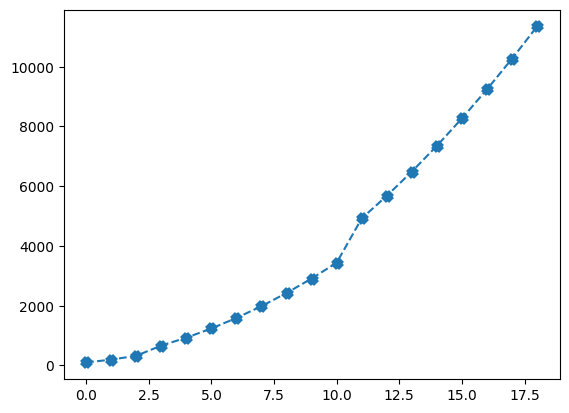

In [29]:
fig, ax = plt.subplots()
ax.plot(n_qubits, 'x--', markeredgewidth=5)
plt.show()